In [1]:
# -*- coding: utf-8 -*-
"""
================================================================================
# Analisis Komparatif Strategi Penanganan Ketidakseimbangan Kelas (4 Eksperimen)
#
# **Tujuan:** Membandingkan 4 strategi:
# 1.  Baseline
# 2.  Weighted Loss
# 3.  Minority Oversampling
# 4.  Kombinasi (Oversampling + Weighted Loss) - [REKOMENDASI BARU]
#
================================================================================
"""

"""
## Langkah 1: Setup, Import Library & Mount Drive
"""

print("Blok 1: Mengimpor library dan Mount Google Drive...")

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import random
from google.colab import drive

# --- Otomatis Mount Google Drive ---
try:
    drive.mount('/content/drive', force_remount=True)
    print("\nGoogle Drive berhasil di-mount di /content/drive")
except Exception as e:
    print(f"Error mounting drive: {e}")
    raise SystemExit("Gagal mount drive. Hentikan eksekusi.")

print("Blok 1: Selesai.")

Blok 1: Mengimpor library dan Mount Google Drive...
Mounted at /content/drive

Google Drive berhasil di-mount di /content/drive
Blok 1: Selesai.



Blok 2: Memuat path data dan mendefinisikan konstanta...
Membaca data dari: /content/drive/MyDrive/JAMBU_BIJI/train
Membaca data dari: /content/drive/MyDrive/JAMBU_BIJI/val
Membaca data dari: /content/drive/MyDrive/JAMBU_BIJI/test

Data berhasil dimuat:
Total Data Latih (Train): 2647
Total Data Validasi (Val): 755
Total Data Uji (Test):  382

Distribusi Kelas pada Data Latih (Akan digunakan untuk training):
label
Anthracnose      1080
fruit_fly         918
healthy_guava     649
Name: count, dtype: int64

Distribusi Kelas pada Data Validasi:
label
Anthracnose      308
fruit_fly        262
healthy_guava    185
Name: count, dtype: int64


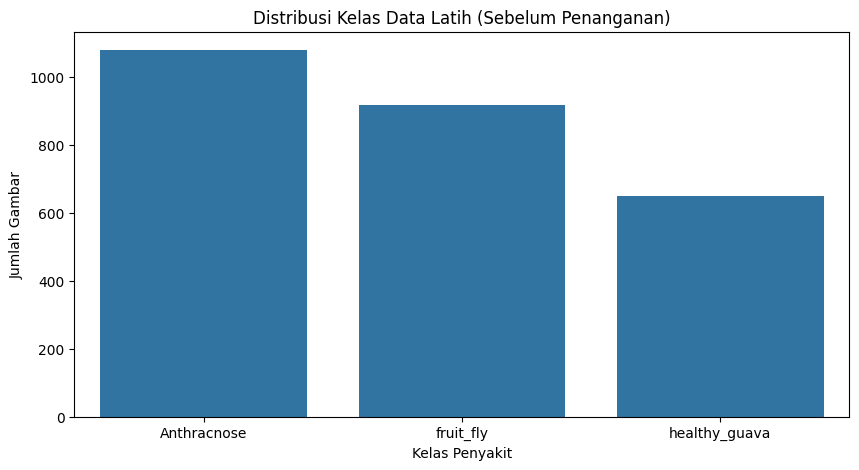

Blok 2: Selesai.


In [2]:
## Langkah 2: Definisi Path, Konstanta, dan Pemuatan Data

print("\nBlok 2: Memuat path data dan mendefinisikan konstanta...")

# --- Konstanta Global ---
BASE_PATH = "/content/drive/MyDrive/JAMBU_BIJI"
TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH = os.path.join(BASE_PATH, "val") # Tambahkan path untuk data validasi
TEST_PATH = os.path.join(BASE_PATH, "test")
LABELS = ["Anthracnose", "fruit_fly", "healthy_guava"]

# Hyperparameter
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 0.0001
# VAL_SPLIT = 0.2 # Tidak perlu lagi karena menggunakan data validasi terpisah
SEED = 42

# --- Fungsi untuk memuat data ---
def load_data_to_dataframe(base_dir):
    data_list = []
    print(f"Membaca data dari: {base_dir}")
    for label in LABELS:
        dir_path = os.path.join(base_dir, label)
        search_pattern = os.path.join(dir_path, "*.*")

        image_files = [f for f in glob.glob(search_pattern)
                       if f.endswith(('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'))]

        if not image_files:
            print(f"  [PERINGATAN] Tidak ada gambar ditemukan di: {dir_path}")

        for f in image_files:
            data_list.append({
                'filepath': f,
                'label': label
            })
    return pd.DataFrame(data_list)

# 1. Muat data training
df_train = load_data_to_dataframe(TRAIN_PATH)

# 2. Muat data validasi
df_val = load_data_to_dataframe(VAL_PATH) # Muat data validasi dari path terpisah

# 3. Muat data testing
df_test = load_data_to_dataframe(TEST_PATH)

if df_train.empty or df_val.empty or df_test.empty: # Periksa semua DataFrame
    print("\n!!! ERROR: Data train, validasi, atau test tidak ditemukan. Pastikan path BASE_PATH sudah benar. Hentikan eksekusi. !!!")
else:
    # # 3. Split data training menjadi TRAIN dan VALIDATION # Baris ini dihapus
    # df_train, df_val = train_test_split(
    #     df_train_full,
    #     test_size=VAL_SPLIT,
    #     random_state=SEED,
    #     stratify=df_train_full['label']
    # )

    print(f"\nData berhasil dimuat:")
    print(f"Total Data Latih (Train): {len(df_train)}") # Ubah pesan
    print(f"Total Data Validasi (Val): {len(df_val)}") # Ubah pesan
    print(f"Total Data Uji (Test):  {len(df_test)}")

    # 4. Cek distribusi kelas pada data latih (yang akan digunakan untuk training)
    print("\nDistribusi Kelas pada Data Latih (Akan digunakan untuk training):")
    label_counts_train = df_train['label'].value_counts() # Gunakan df_train yang sudah dimuat
    print(label_counts_train)

    # Opsional: Cek distribusi kelas pada data validasi
    print("\nDistribusi Kelas pada Data Validasi:")
    label_counts_val = df_val['label'].value_counts()
    print(label_counts_val)

    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_train, x='label', order=LABELS)
    plt.title('Distribusi Kelas Data Latih (Sebelum Penanganan)')
    plt.xlabel('Kelas Penyakit')
    plt.ylabel('Jumlah Gambar')
    plt.show()

print("Blok 2: Selesai.")


Blok 3: Mempersiapkan Generator dan Visualisasi Augmentasi...
Memvisualisasikan hasil preprocessing dan augmentasi...
Mengambil sampel gambar dari kelas: healthy_guava
Path: /content/drive/MyDrive/JAMBU_BIJI/train/healthy_guava/102_unsharp_clahe_augmented_2.png


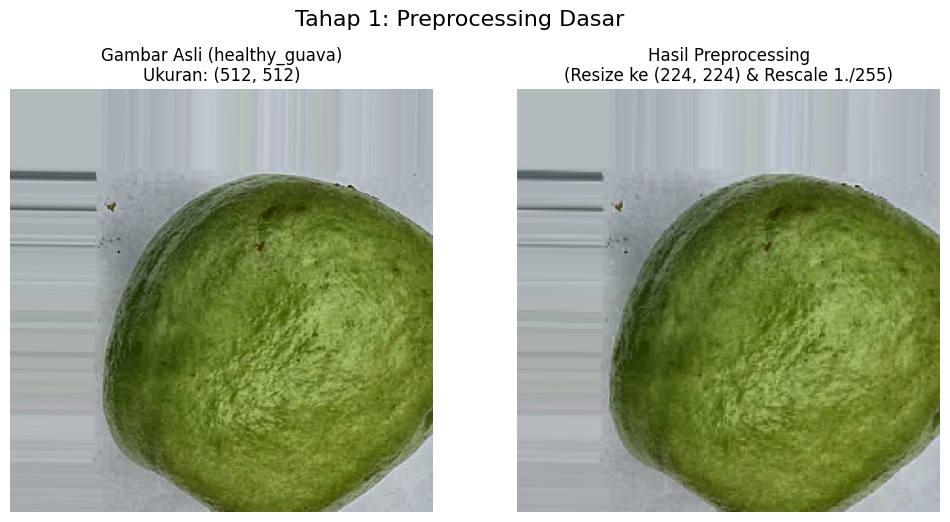

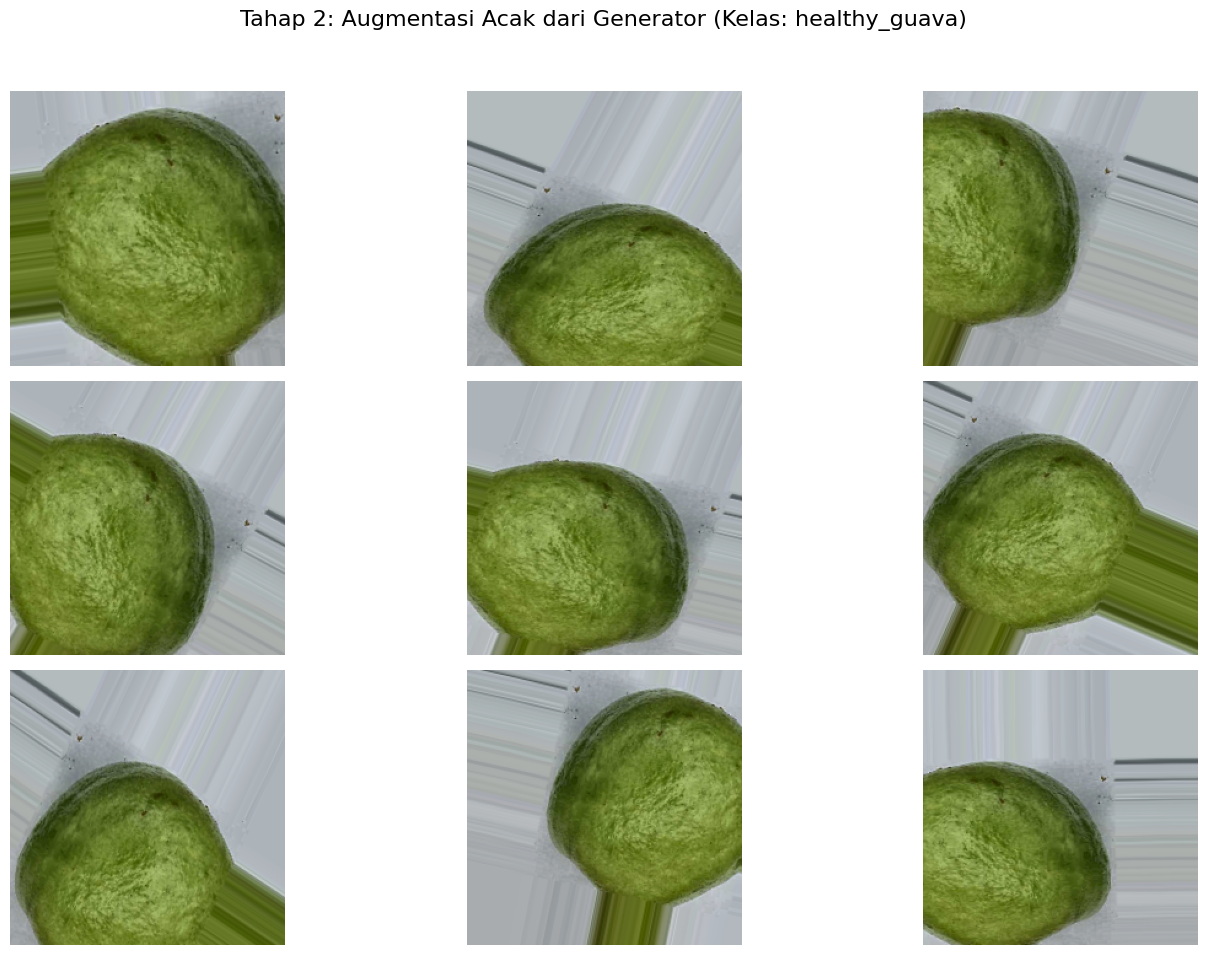

Blok 3: Selesai.


In [3]:
## Langkah 3: Visualisasi Preprocessing dan Augmentasi

print("\nBlok 3: Mempersiapkan Generator dan Visualisasi Augmentasi...")

# 1. Definisikan Generator Augmentasi
train_aug_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=30, width_shift_range=0.2,
    height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
    horizontal_flip=True, fill_mode='nearest'
)
val_test_gen = ImageDataGenerator(rescale=1./255)

# 2. Fungsi Bantuan untuk Visualisasi
def visualize_augmentations(df_train_data, train_gen):
    print("Memvisualisasikan hasil preprocessing dan augmentasi...")
    try:
        minority_class = 'healthy_guava'
        if minority_class not in df_train_data['label'].values:
            print(f"Kelas '{minority_class}' tidak ditemukan, mengambil gambar acak.")
            sample_path = df_train_data['filepath'].iloc[0]
            sample_label = df_train_data['label'].iloc[0]
        else:
            sample_path = df_train_data[df_train_data['label'] == minority_class]['filepath'].iloc[0]
            sample_label = minority_class

        print(f"Mengambil sampel gambar dari kelas: {sample_label}")
        print(f"Path: {sample_path}")

        img = load_img(sample_path)
        img_array = img_to_array(img)

        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Gambar Asli ({sample_label})\nUkuran: {img_array.shape[:2]}")
        plt.axis('off')

        img_resized = load_img(sample_path, target_size=IMG_SIZE)
        img_rescaled_array = val_test_gen.standardize(img_to_array(img_resized))

        plt.subplot(1, 2, 2)
        plt.imshow(img_rescaled_array)
        plt.title(f"Hasil Preprocessing\n(Resize ke {IMG_SIZE} & Rescale 1./255)")
        plt.axis('off')
        plt.suptitle("Tahap 1: Preprocessing Dasar", fontsize=16)
        plt.show()

        img_batch = np.expand_dims(img_to_array(img_resized), axis=0)
        plt.figure(figsize=(15, 10))
        plt.suptitle(f"Tahap 2: Augmentasi Acak dari Generator (Kelas: {sample_label})", fontsize=16)

        i = 0
        for batch in train_gen.flow(img_batch, batch_size=1, seed=SEED):
            plt.subplot(3, 3, i + 1)
            plt.imshow(batch[0])
            plt.axis('off')
            i += 1
            if i % 9 == 0:
                break

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    except Exception as e:
        print(f"\n!!! Gagal memvisualisasikan augmentasi: {e}")

# 3. Jalankan Visualisasi
if 'df_train' in locals() and not df_train.empty:
    temp_vis_gen = ImageDataGenerator(
        rescale=1./255, rotation_range=30, width_shift_range=0.2,
        height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
        horizontal_flip=True, fill_mode='nearest'
    )
    visualize_augmentations(df_train, temp_vis_gen)
else:
    print("\nDataFrame latih kosong, visualisasi dilewati.")

print("Blok 3: Selesai.")



In [4]:
## Langkah 4: Definisi Model (MobileNetV2)

print("\nBlok 4: Mendefinisikan arsitektur model...")

def build_model(num_classes):
    base_model = MobileNetV2(
        weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

num_classes = len(LABELS)
test_model = build_model(num_classes)
print("Arsitektur Model (Contoh):")
test_model.summary()
print("Blok 4: Selesai.")


Blok 4: Mendefinisikan arsitektur model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Arsitektur Model (Contoh):


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Blok 4: Selesai.


In [5]:
## Langkah 5: Eksperimen 1 - Model Baseline (Tanpa Penanganan)

print("\n" + "="*80)
print("       EKSPERIMEN 1: MODEL BASELINE (TANPA PENANGANAN)")
print("="*80)

# 1. Buat generator data latih & validasi
train_generator_baseline = train_aug_gen.flow_from_dataframe(
    dataframe=df_train, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, class_mode='categorical',
    batch_size=BATCH_SIZE, shuffle=True, seed=SEED
)

val_generator = val_test_gen.flow_from_dataframe(
    dataframe=df_val, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, class_mode='categorical',
    batch_size=BATCH_SIZE, shuffle=False
)

# 2. Build model
model_baseline = build_model(num_classes)

# 3. Latih model
print("\nMulai melatih Model Baseline...")
history_baseline = model_baseline.fit(
    train_generator_baseline,
    steps_per_epoch=len(train_generator_baseline),
    validation_data=val_generator,
    validation_steps=len(val_generator),
    epochs=EPOCHS,
    verbose=1
)

print("Pelatihan Model Baseline Selesai.")
print("Blok 5: Selesai.")



       EKSPERIMEN 1: MODEL BASELINE (TANPA PENANGANAN)
Found 2647 validated image filenames belonging to 3 classes.
Found 755 validated image filenames belonging to 3 classes.

Mulai melatih Model Baseline...
Epoch 1/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 1380s 16s/step - accuracy: 0.6887 - loss: 0.7260 - val_accuracy: 0.9033 - val_loss: 0.3580
Epoch 2/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 72s 869ms/step - accuracy: 0.8867 - loss: 0.3361 - val_accuracy: 0.9285 - val_loss: 0.2246
Epoch 3/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 71s 862ms/step - accuracy: 0.9150 - loss: 0.2550 - val_accuracy: 0.9563 - val_loss: 0.1517
Epoch 4/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 72s 871ms/step - accuracy: 0.9275 - loss: 0.2200 - val_accuracy: 0.9603 - val_loss: 0.1201
Epoch 5/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 71s 853ms/step - accuracy: 0.9418 - loss: 0.1765 - val_accuracy: 0.9695 - val_loss: 0.1008
Pelatihan Model Baseline Selesai.
Blok 5: Selesai.


In [6]:
## Langkah 6: Eksperimen 2 - Model Weighted Loss

print("\n" + "="*80)
print("       EKSPERIMEN 2: MODEL DENGAN WEIGHTED LOSS")
print("="*80)

# 1. Hitung Class Weights
labels_int = df_train['label'].astype('category').cat.codes
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_int),
    y=labels_int
)
class_indices = train_generator_baseline.class_indices
weights_dict = {class_indices[label]: weight for label, weight in zip(np.unique(df_train['label']), class_weights_array)}

print(f"Class weights yang akan digunakan (Index: Bobot):")
print(weights_dict)

# 2. Buat generator
train_generator_weighted = train_aug_gen.flow_from_dataframe(
    dataframe=df_train, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, class_mode='categorical',
    batch_size=BATCH_SIZE, shuffle=True, seed=SEED
)

# 3. Build model
model_weighted = build_model(num_classes)

# 4. Latih model
print("\nMulai melatih Model Weighted Loss...")
history_weighted = model_weighted.fit(
    train_generator_weighted,
    steps_per_epoch=len(train_generator_weighted),
    validation_data=val_generator,
    validation_steps=len(val_generator),
    epochs=EPOCHS,
    class_weight=weights_dict, # Menerapkan class weight
    verbose=1
)

print("Pelatihan Model Weighted Loss Selesai.")
print("Blok 6: Selesai.")


       EKSPERIMEN 2: MODEL DENGAN WEIGHTED LOSS
Class weights yang akan digunakan (Index: Bobot):
{0: np.float64(0.8169753086419753), 1: np.float64(0.9611474219317356), 2: np.float64(1.359527478171546)}
Found 2647 validated image filenames belonging to 3 classes.

Mulai melatih Model Weighted Loss...
Epoch 1/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.6940 - loss: 0.7327 - val_accuracy: 0.8728 - val_loss: 0.3516
Epoch 2/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 69s 837ms/step - accuracy: 0.8810 - loss: 0.3549 - val_accuracy: 0.9457 - val_loss: 0.1903
Epoch 3/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 82s 830ms/step - accuracy: 0.9131 - loss: 0.2582 - val_accuracy: 0.9483 - val_loss: 0.1579
Epoch 4/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 72s 869ms/step - accuracy: 0.9373 - loss: 0.2013 - val_accuracy: 0.9603 - val_loss: 0.1164
Epoch 5/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 70s 840ms/step - accuracy: 0.9399 - loss: 0.1802 - val_accuracy: 0.9616 - val_loss: 0.1099
Pelatihan Model Weighted Loss Selesai.
Blok 6: Selesai.


In [7]:
## Langkah 7: Eksperimen 3 - Minority Oversampling

print("\n" + "="*80)
print("       EKSPERIMEN 3: MODEL DENGAN MINORITY OVERSAMPLING")
print("="*80)

# 1. Tentukan jumlah target (count dari kelas mayoritas)
if 'label_counts_train' not in locals():
    label_counts_train = df_train['label'].value_counts()

max_count = label_counts_train.max()
print(f"Distribusi Asli: \n{label_counts_train}")
print(f"Target Oversampling (menyamai kelas mayoritas): {max_count} sampel per kelas.")

# 2. Buat DataFrame baru yang seimbang (balanced)
df_list = []
for label in LABELS:
    df_class = df_train[df_train['label'] == label]
    df_class_oversampled = df_class.sample(n=max_count, replace=True, random_state=SEED)
    df_list.append(df_class_oversampled)

df_train_balanced = pd.concat(df_list)

# 3. Acak (shuffle) DataFrame
df_train_balanced = df_train_balanced.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nDistribusi Kelas pada Data Latih (Setelah Oversampling):")
print(df_train_balanced['label'].value_counts())

# 4. Buat generator data latih dari DataFrame seimbang
train_generator_oversampled = train_aug_gen.flow_from_dataframe(
    dataframe=df_train_balanced,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

# 5. Build model
model_oversampled = build_model(num_classes)

# 6. Latih model
print("\nMulai melatih Model Oversampled...")
history_oversampled = model_oversampled.fit(
    train_generator_oversampled,
    steps_per_epoch=len(train_generator_oversampled),
    validation_data=val_generator,
    validation_steps=len(val_generator),
    epochs=EPOCHS,
    verbose=1
)

print("Pelatihan Model Oversampled Selesai.")
print("Blok 7: Selesai.")



       EKSPERIMEN 3: MODEL DENGAN MINORITY OVERSAMPLING
Distribusi Asli: 
label
Anthracnose      1080
fruit_fly         918
healthy_guava     649
Name: count, dtype: int64
Target Oversampling (menyamai kelas mayoritas): 1080 sampel per kelas.

Distribusi Kelas pada Data Latih (Setelah Oversampling):
label
healthy_guava    1080
fruit_fly        1080
Anthracnose      1080
Name: count, dtype: int64
Found 3240 validated image filenames belonging to 3 classes.

Mulai melatih Model Oversampled...
Epoch 1/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.7414 - loss: 0.6266 - val_accuracy: 0.9126 - val_loss: 0.2711
Epoch 2/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 85s 834ms/step - accuracy: 0.8978 - loss: 0.2881 - val_accuracy: 0.9563 - val_loss: 0.1631
Epoch 3/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 85s 834ms/step - accuracy: 0.9204 - loss: 0.2211 - val_accuracy: 0.9669 - val_loss: 0.1229
Epoch 4/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 84s 826ms/step - accuracy: 0.9367 - loss: 0.1839 - val_accuracy: 0.9682 - va

In [8]:
"""
## Langkah 8: (BARU) Eksperimen 4 - Kombinasi (Oversampling + Weighted Loss)
Ini adalah langkah yang disarankan untuk memenuhi Poin Novelty 3 (Potensi kombinasi kedua strategi).
"""

print("\n" + "="*80)
print("       EKSPERIMEN 4: KOMBINASI (OVERSAMPLING + WEIGHTED LOSS)")
print("="*80)

# 1. Kita menggunakan generator data yang sudah di-oversampling (balanced)
# dari Blok 7 (train_generator_oversampled)

# 2. Kita menggunakan bobot (weights_dict) dari Blok 6.
# Meskipun datanya sudah seimbang, penerapan bobot masih bisa
# memberi "penekanan ekstra" pada kelas yang secara alami minoritas.
print(f"Class weights yang akan digunakan (Index: Bobot):")
print(weights_dict)

# 3. Build model
model_combined = build_model(num_classes)

# 4. Latih model
print("\nMulai melatih Model Kombinasi (Oversampling + Weighted Loss)...")
history_combined = model_combined.fit(
    train_generator_oversampled, # Menggunakan generator balanced
    steps_per_epoch=len(train_generator_oversampled),
    validation_data=val_generator,
    validation_steps=len(val_generator),
    epochs=EPOCHS,
    class_weight=weights_dict, # TETAP menerapkan class weight
    verbose=1
)

print("Pelatihan Model Kombinasi Selesai.")
print("Blok 8: Selesai.")


       EKSPERIMEN 4: KOMBINASI (OVERSAMPLING + WEIGHTED LOSS)
Class weights yang akan digunakan (Index: Bobot):
{0: np.float64(0.8169753086419753), 1: np.float64(0.9611474219317356), 2: np.float64(1.359527478171546)}

Mulai melatih Model Kombinasi (Oversampling + Weighted Loss)...
Epoch 1/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 104s 920ms/step - accuracy: 0.7185 - loss: 0.6709 - val_accuracy: 0.9113 - val_loss: 0.2737
Epoch 2/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 124s 802ms/step - accuracy: 0.8880 - loss: 0.3127 - val_accuracy: 0.9576 - val_loss: 0.1603
Epoch 3/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 82s 809ms/step - accuracy: 0.9204 - loss: 0.2252 - val_accuracy: 0.9589 - val_loss: 0.1334
Epoch 4/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 84s 827ms/step - accuracy: 0.9330 - loss: 0.1985 - val_accuracy: 0.9722 - val_loss: 0.0969
Epoch 5/5
102/102 ━━━━━━━━━━━━━━━━━━━━ 82s 802ms/step - accuracy: 0.9380 - loss: 0.1671 - val_accuracy: 0.9828 - val_loss: 0.0765
Pelatihan Model Kombinasi Selesai.
Blok 8: Selesai.



       BLOK 9: EVALUASI AKHIR & PERBANDINGAN KOMPARATIF

--- 1. Perbandingan Kurva Pelatihan Model ---


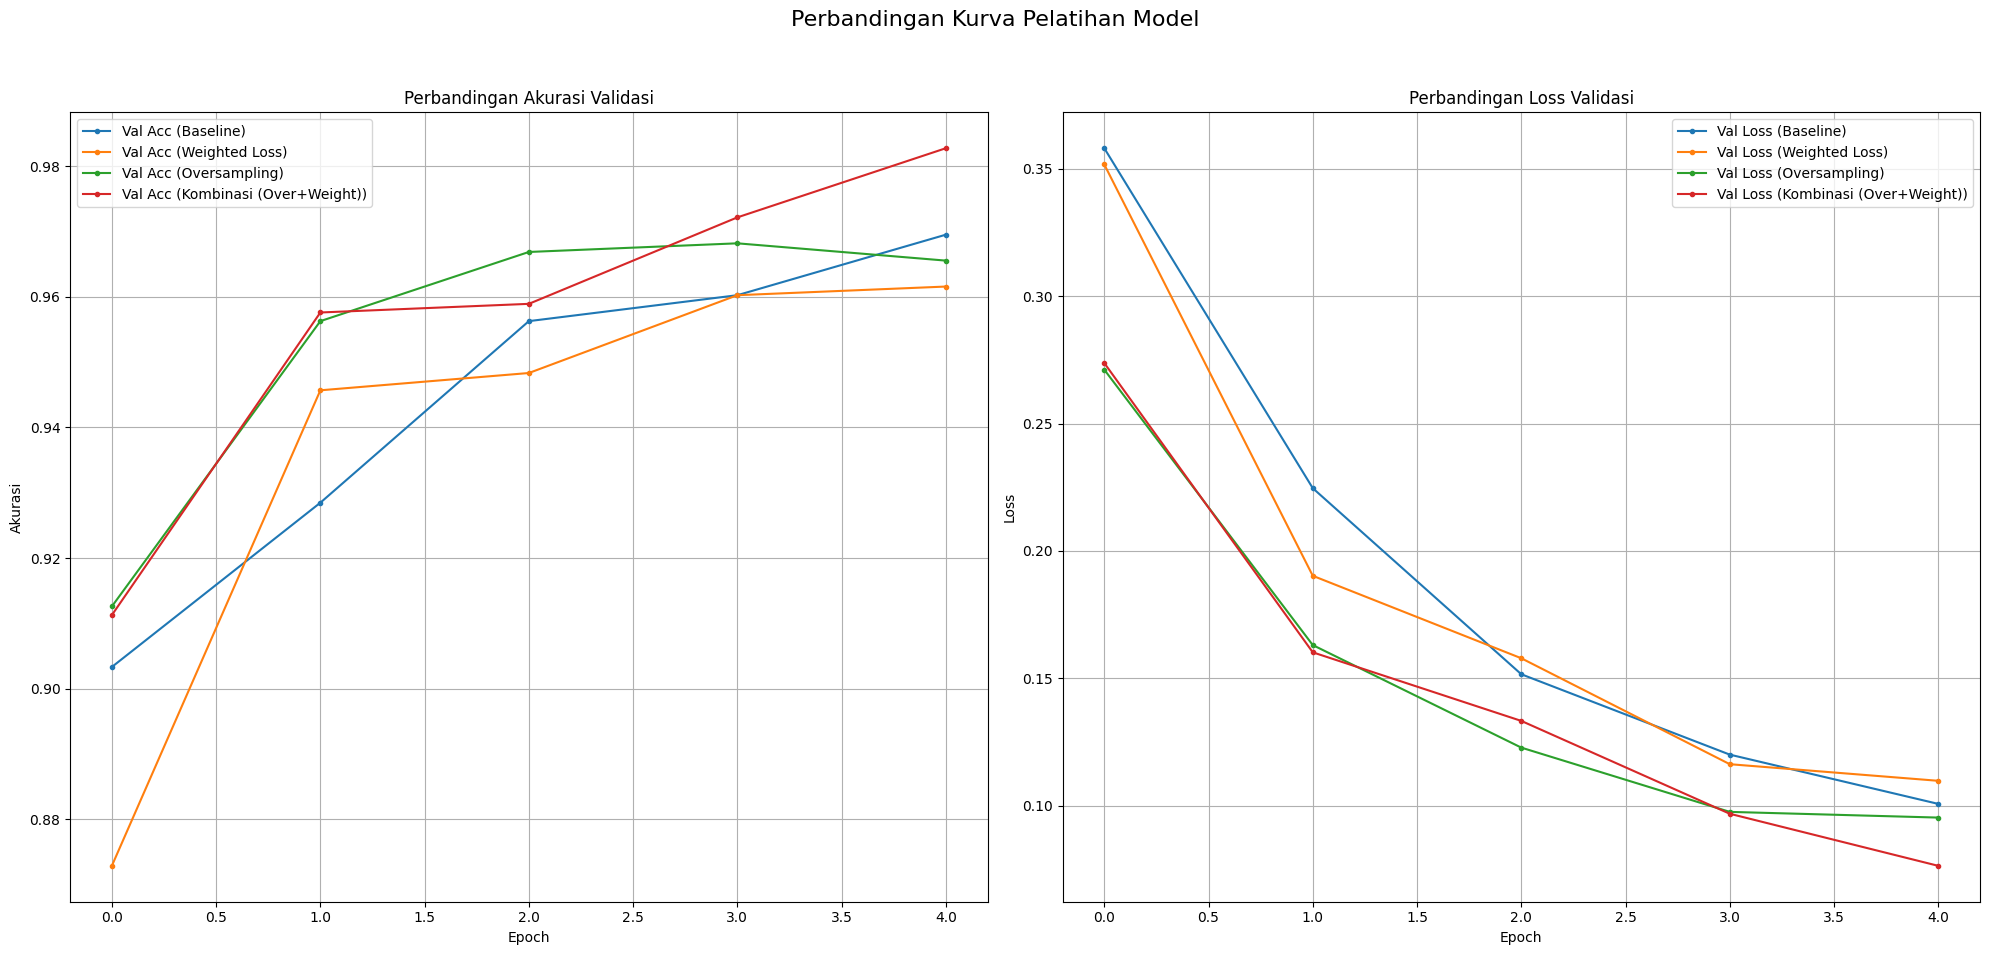


--- 2. Mengevaluasi performa pada TEST SET (Data Tak Terlihat) ---
Found 382 validated image filenames belonging to 3 classes.
Label map (Index -> Kelas): {'Anthracnose': 0, 'fruit_fly': 1, 'healthy_guava': 2}

--- Hasil untuk Model: Baseline ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 190s 17s/step - accuracy: 0.9555 - loss: 0.1353
Test Loss:     0.1353
Test Accuracy: 0.9555
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 878ms/step

--- Hasil untuk Model: Weighted Loss ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 759ms/step - accuracy: 0.9476 - loss: 0.1648
Test Loss:     0.1648
Test Accuracy: 0.9476
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 817ms/step

--- Hasil untuk Model: Oversampling ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 710ms/step - accuracy: 0.9555 - loss: 0.1382
Test Loss:     0.1382
Test Accuracy: 0.9555
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 802ms/step

--- Hasil untuk Model: Kombinasi (Over+Weight) ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 638ms/step - accuracy: 0.9581 - loss: 0.1127
Test Loss:     0.1127
Test Accuracy: 0.9581
12/12 ━━━━━━━━━

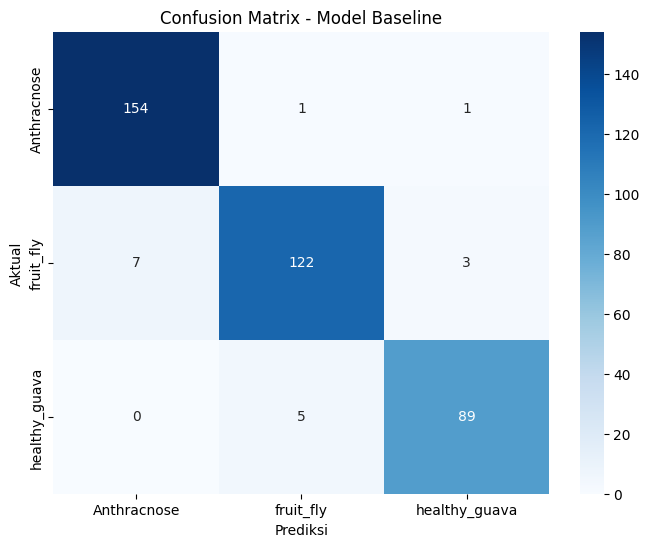


            LAPORAN UNTUK MODEL: Weighted Loss
               precision    recall  f1-score   support

  Anthracnose       0.92      0.99      0.95       156
    fruit_fly       0.97      0.90      0.93       132
healthy_guava       0.98      0.94      0.96        94

     accuracy                           0.95       382
    macro avg       0.95      0.94      0.95       382
 weighted avg       0.95      0.95      0.95       382



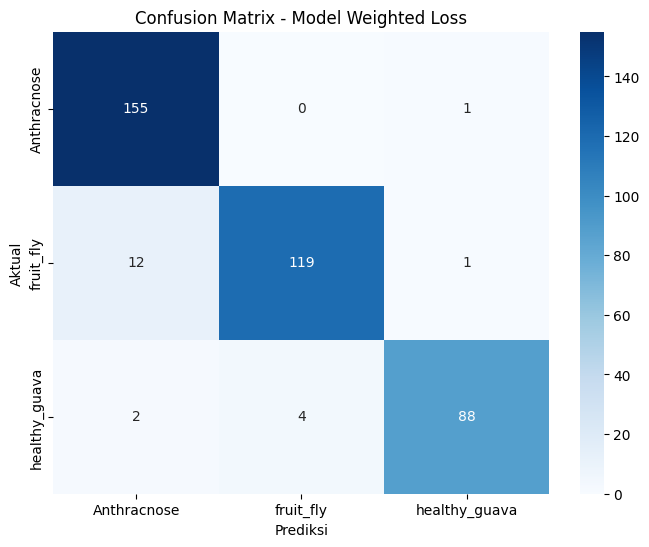


            LAPORAN UNTUK MODEL: Oversampling
               precision    recall  f1-score   support

  Anthracnose       0.94      0.99      0.97       156
    fruit_fly       0.96      0.92      0.94       132
healthy_guava       0.98      0.94      0.96        94

     accuracy                           0.96       382
    macro avg       0.96      0.95      0.95       382
 weighted avg       0.96      0.96      0.96       382



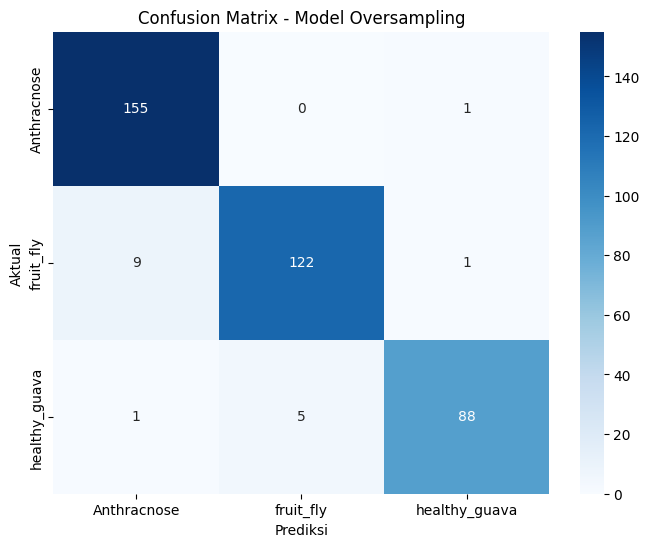


            LAPORAN UNTUK MODEL: Kombinasi (Over+Weight)
               precision    recall  f1-score   support

  Anthracnose       0.95      0.99      0.97       156
    fruit_fly       0.96      0.92      0.94       132
healthy_guava       0.97      0.96      0.96        94

     accuracy                           0.96       382
    macro avg       0.96      0.96      0.96       382
 weighted avg       0.96      0.96      0.96       382



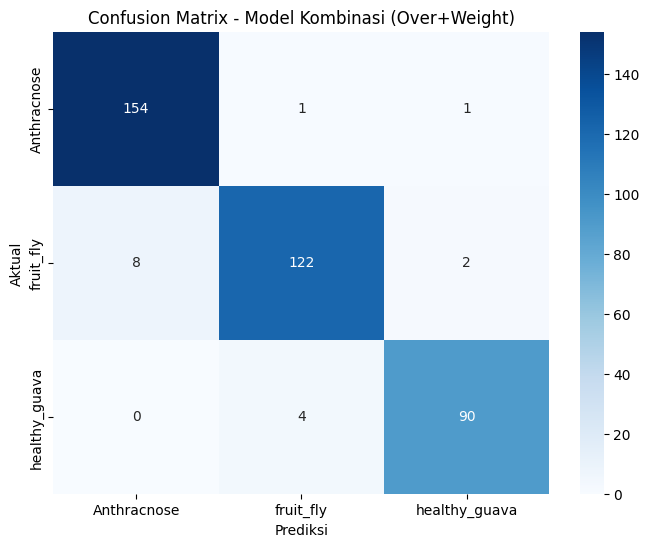


     TABEL KESIMPULAN PERBANDINGAN (F1-SCORE & AKURASI) - 4 MODEL
| Model                   |   Anthracnose |   fruit_fly |   healthy_guava |   Macro Avg F1 |   Accuracy |
|:------------------------|--------------:|------------:|----------------:|---------------:|-----------:|
| Baseline                |        0.9716 |      0.9385 |          0.9519 |         0.9540 |     0.9555 |
| Weighted Loss           |        0.9538 |      0.9333 |          0.9565 |         0.9479 |     0.9476 |
| Oversampling            |        0.9657 |      0.9421 |          0.9565 |         0.9548 |     0.9555 |
| Kombinasi (Over+Weight) |        0.9686 |      0.9421 |          0.9626 |         0.9577 |     0.9581 |

--- 5. ANALISIS & INTERPRETASI HASIL ---
Analisis berfokus pada perbaikan F1-Score kelas minoritas: 'healthy_guava'

F1-Score Kelas Minoritas ('healthy_guava'):
  Baseline:                0.9519
  Weighted Loss:           0.9565 (Perubahan: +0.0047)
  Oversampling:            0.9565 (Perubahan: 

In [9]:
"""
## Langkah 9: Evaluasi Akhir & Perbandingan Komparatif (4 Model)
Membandingkan performa keempat model pada **Data Uji (Test Set)**.
"""

print("\n" + "="*80)
print("       BLOK 9: EVALUASI AKHIR & PERBANDINGAN KOMPARATIF")
print("="*80)

# Kumpulkan semua model dan history
models = {
    "Baseline": model_baseline,
    "Weighted Loss": model_weighted,
    "Oversampling": model_oversampled,
    "Kombinasi (Over+Weight)": model_combined  # Ditambahkan
}

histories = {
    "Baseline": history_baseline,
    "Weighted Loss": history_weighted,
    "Oversampling": history_oversampled,
    "Kombinasi (Over+Weight)": history_combined # Ditambahkan
}

# --- 1. Plot Kurva Training & Validation ---
print("\n--- 1. Perbandingan Kurva Pelatihan Model ---")
plt.figure(figsize=(20, 10))

# Plot Accuracy
plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=f'Val Acc ({name})', marker='o', markersize=3)
plt.title('Perbandingan Akurasi Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(history.history['val_loss'], label=f'Val Loss ({name})', marker='o', markersize=3)
plt.title('Perbandingan Loss Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.suptitle('Perbandingan Kurva Pelatihan Model', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- 2. Evaluasi pada Test Set ---
print("\n--- 2. Mengevaluasi performa pada TEST SET (Data Tak Terlihat) ---")

# Buat generator data uji (HANYA RESCALE)
test_generator = val_test_gen.flow_from_dataframe(
    dataframe=df_test,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

y_true = test_generator.classes
y_true_labels = [LABELS[k] for k in y_true]
label_map = test_generator.class_indices
print(f"Label map (Index -> Kelas): {label_map}")

results = {}

for name, model in models.items():
    print(f"\n--- Hasil untuk Model: {name} ---")

    loss, accuracy = model.evaluate(test_generator)
    print(f"Test Loss:     {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")

    y_pred_probs = model.predict(test_generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_pred_labels = [LABELS[k] for k in y_pred]

    results[name] = {
        'loss': loss,
        'accuracy': accuracy,
        'report_dict': classification_report(y_true_labels, y_pred_labels, target_names=LABELS, output_dict=True),
        'report_text': classification_report(y_true_labels, y_pred_labels, target_names=LABELS),
        'cm': confusion_matrix(y_true_labels, y_pred_labels, labels=LABELS)
    }

# --- 3. Tampilkan Laporan Klasifikasi & Confusion Matrix per Model ---
print("\n--- 3. Laporan Rinci Performa Test Set ---")

f1_scores = []

for name, res in results.items():
    print("\n" + "="*50)
    print(f"            LAPORAN UNTUK MODEL: {name}")
    print("="*50)

    print(res['report_text'])

    report = res['report_dict']
    f1_scores.append({
        'Model': name,
        LABELS[0]: report[LABELS[0]]['f1-score'],
        LABELS[1]: report[LABELS[1]]['f1-score'],
        LABELS[2]: report[LABELS[2]]['f1-score'],
        'Macro Avg F1': report['macro avg']['f1-score'],
        'Accuracy': report['accuracy']
    })

    plt.figure(figsize=(8, 6))
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS)
    plt.title(f'Confusion Matrix - Model {name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

# --- 4. Tampilkan Tabel Perbandingan Akhir ---
print("\n" + "="*80)
print("     TABEL KESIMPULAN PERBANDINGAN (F1-SCORE & AKURASI) - 4 MODEL")
print("="*80)

df_results = pd.DataFrame(f1_scores).set_index('Model')
print(df_results.to_markdown(floatfmt=".4f"))


# --- 5. Kesimpulan Analisis (Interpretasi Pakar) ---
print("\n--- 5. ANALISIS & INTERPRETASI HASIL ---")

minority_class_name = label_counts_train.idxmin()
majority_class_name = label_counts_train.idxmax()

print(f"Analisis berfokus pada perbaikan F1-Score kelas minoritas: '{minority_class_name}'")

baseline_f1_minority = df_results.loc['Baseline', minority_class_name]
weighted_f1_minority = df_results.loc['Weighted Loss', minority_class_name]
oversample_f1_minority = df_results.loc['Oversampling', minority_class_name]
combined_f1_minority = df_results.loc['Kombinasi (Over+Weight)', minority_class_name]

baseline_f1_macro = df_results.loc['Baseline', 'Macro Avg F1']
weighted_f1_macro = df_results.loc['Weighted Loss', 'Macro Avg F1']
oversample_f1_macro = df_results.loc['Oversampling', 'Macro Avg F1']
combined_f1_macro = df_results.loc['Kombinasi (Over+Weight)', 'Macro Avg F1']

print(f"\nF1-Score Kelas Minoritas ('{minority_class_name}'):")
print(f"  Baseline:                {baseline_f1_minority:.4f}")
print(f"  Weighted Loss:           {weighted_f1_minority:.4f} (Perubahan: {weighted_f1_minority - baseline_f1_minority:+.4f})")
print(f"  Oversampling:            {oversample_f1_minority:.4f} (Perubahan: {oversample_f1_minority - baseline_f1_minority:+.4f})")
print(f"  Kombinasi (Over+Weight): {combined_f1_minority:.4f} (Perubahan: {combined_f1_minority - baseline_f1_minority:+.4f})")

print(f"\nMacro Avg F1-Score (Keseimbangan Total):")
print(f"  Baseline:                {baseline_f1_macro:.4f}")
print(f"  Weighted Loss:           {weighted_f1_macro:.4f} (Perubahan: {weighted_f1_macro - baseline_f1_macro:+.4f})")
print(f"  Oversampling:            {oversample_f1_macro:.4f} (Perubahan: {oversample_f1_macro - baseline_f1_macro:+.4f})")
print(f"  Kombinasi (Over+Weight): {combined_f1_macro:.4f} (Perubahan: {combined_f1_macro - baseline_f1_macro:+.4f})")

print("\n**Rekomendasi:**")
print("Bandingkan hasil dari 4 model ini. Model 'Kombinasi' seringkali memberikan performa paling seimbang,")
print("karena ia tidak hanya 'melihat' lebih banyak contoh kelas minoritas (dari oversampling),")
print("tetapi juga 'dipaksa' untuk lebih memperhatikannya (dari weighted loss).")

print("\n\nStudi Komparatif Selesai.")
print("Blok 9: Selesai.")


In [10]:
print("\n--- Menyimpan Model-Model yang Telah Dilatih ---")

# Direktori untuk menyimpan model
SAVE_DIR = os.path.join(BASE_PATH, "saved_models")
os.makedirs(SAVE_DIR, exist_ok=True)

for name, model in models.items():
    model_name_h5 = os.path.join(SAVE_DIR, f"{name.replace(' ', '_').replace('+', '_')}.h5")
    model_name_keras = os.path.join(SAVE_DIR, f"{name.replace(' ', '_').replace('+', '_')}.keras")

    try:
        model.save(model_name_h5)
        print(f"Model '{name}' berhasil disimpan ke {model_name_h5}")
    except Exception as e:
        print(f"Gagal menyimpan model '{name}' ke .h5: {e}")

    try:
        model.save(model_name_keras)
        print(f"Model '{name}' berhasil disimpan ke {model_name_keras}")
    except Exception as e:
        print(f"Gagal menyimpan model '{name}' ke .keras: {e}")

print("Penyimpanan model selesai.")


--- Menyimpan Model-Model yang Telah Dilatih ---


Model 'Baseline' berhasil disimpan ke /content/drive/MyDrive/JAMBU_BIJI/saved_models/Baseline.h5


Model 'Baseline' berhasil disimpan ke /content/drive/MyDrive/JAMBU_BIJI/saved_models/Baseline.keras
Model 'Weighted Loss' berhasil disimpan ke /content/drive/MyDrive/JAMBU_BIJI/saved_models/Weighted_Loss.h5


Model 'Weighted Loss' berhasil disimpan ke /content/drive/MyDrive/JAMBU_BIJI/saved_models/Weighted_Loss.keras
Model 'Oversampling' berhasil disimpan ke /content/drive/MyDrive/JAMBU_BIJI/saved_models/Oversampling.h5


Model 'Oversampling' berhasil disimpan ke /content/drive/MyDrive/JAMBU_BIJI/saved_models/Oversampling.keras
Model 'Kombinasi (Over+Weight)' berhasil disimpan ke /content/drive/MyDrive/JAMBU_BIJI/saved_models/Kombinasi_(Over_Weight).h5
Model 'Kombinasi (Over+Weight)' berhasil disimpan ke /content/drive/MyDrive/JAMBU_BIJI/saved_models/Kombinasi_(Over_Weight).keras
Penyimpanan model selesai.



--- Memvisualisasikan Tabel Perbandingan F1-Score dan Akurasi ---


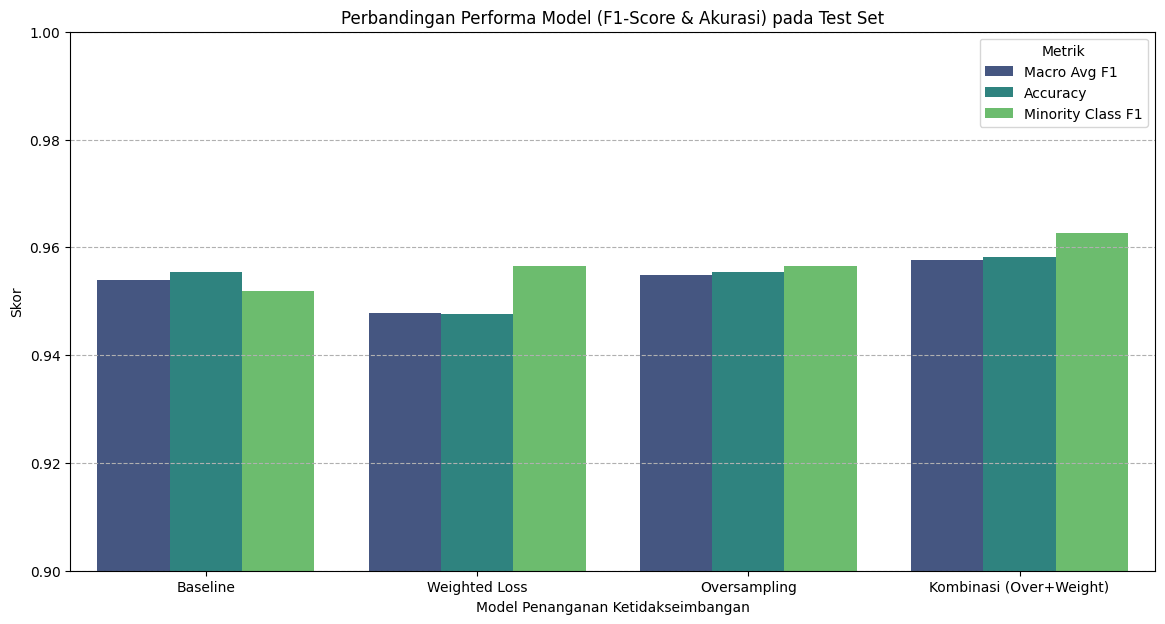

Visualisasi selesai.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pastikan df_results sudah ada dan berisi data perbandingan
if 'df_results' in locals() and not df_results.empty:

    print("\n--- Memvisualisasikan Tabel Perbandingan F1-Score dan Akurasi ---")

    df_plot = df_results[['Macro Avg F1', 'Accuracy', 'healthy_guava']].rename(
        columns={'healthy_guava': 'Minority Class F1'} # Ubah nama kolom minoritas agar lebih jelas
    ).reset_index()

    # Melt the DataFrame for easier plotting with seaborn
    df_plot_melted = df_plot.melt(id_vars='Model', var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.barplot(data=df_plot_melted, x='Model', y='Score', hue='Metric', palette='viridis')
    plt.title('Perbandingan Performa Model (F1-Score & Akurasi) pada Test Set')
    plt.xlabel('Model Penanganan Ketidakseimbangan')
    plt.ylabel('Skor')
    plt.ylim(0.9, 1.0) # Fokuskan plot pada rentang skor yang relevan
    plt.legend(title='Metrik')
    plt.grid(axis='y', linestyle='--')
    plt.show()

    print("Visualisasi selesai.")

else:
    print("\nDataFrame df_results tidak ditemukan atau kosong. Jalankan kembali Blok 9 terlebih dahulu.")


--- Memvisualisasikan Tabel Perbandingan F1-Score dan Akurasi (Baseline, Weighted Loss, Oversampling) ---


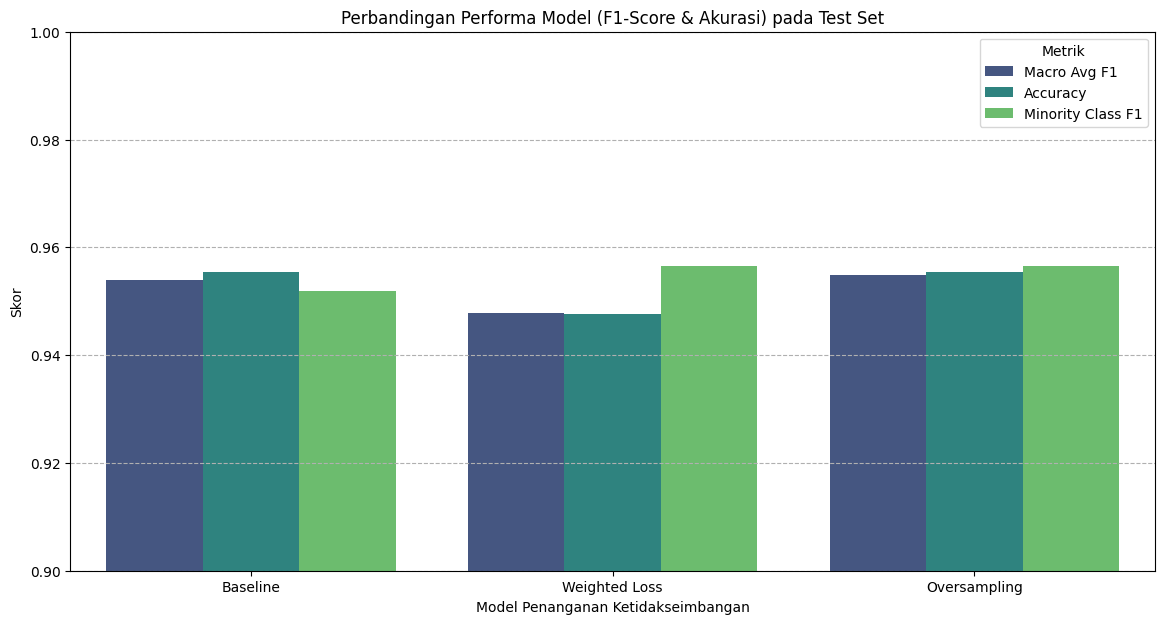

Visualisasi selesai.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pastikan df_results sudah ada dan berisi data perbandingan
if 'df_results' in locals() and not df_results.empty:

    print("\n--- Memvisualisasikan Tabel Perbandingan F1-Score dan Akurasi (Baseline, Weighted Loss, Oversampling) ---")

    # Filter data untuk hanya menyertakan model yang diminta
    models_to_plot = ['Baseline', 'Weighted Loss', 'Oversampling']
    df_plot = df_results.loc[models_to_plot, ['Macro Avg F1', 'Accuracy', 'healthy_guava']].rename(
        columns={'healthy_guava': 'Minority Class F1'} # Ubah nama kolom minoritas agar lebih jelas
    ).reset_index()

    # Melt the DataFrame for easier plotting with seaborn
    df_plot_melted = df_plot.melt(id_vars='Model', var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    sns.barplot(data=df_plot_melted, x='Model', y='Score', hue='Metric', palette='viridis')
    plt.title('Perbandingan Performa Model (F1-Score & Akurasi) pada Test Set')
    plt.xlabel('Model Penanganan Ketidakseimbangan')
    plt.ylabel('Skor')
    plt.ylim(0.9, 1.0) # Fokuskan plot pada rentang skor yang relevan
    plt.legend(title='Metrik')
    plt.grid(axis='y', linestyle='--')
    plt.show()

    print("Visualisasi selesai.")

else:
    print("\nDataFrame df_results tidak ditemukan atau kosong. Jalankan kembali Blok 9 terlebih dahulu.")


--- Memvisualisasikan Perbandingan F1-Score per Kelas (Baseline, Weighted Loss, Oversampling) ---


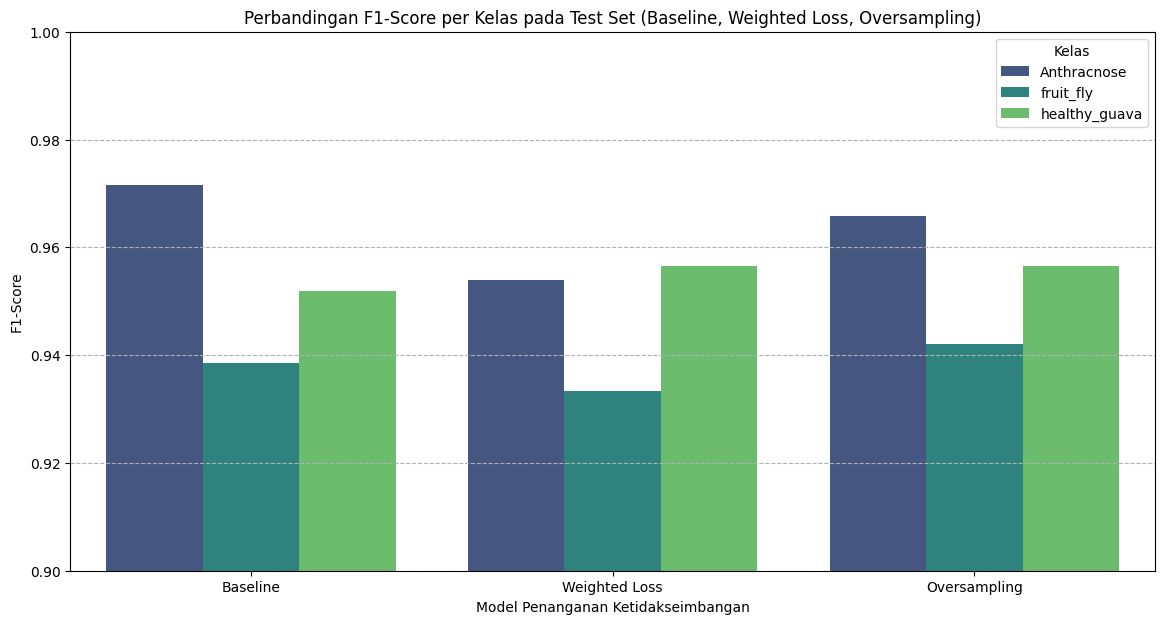

Visualisasi selesai.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pastikan df_results sudah ada dan berisi data perbandingan
if 'df_results' in locals() and not df_results.empty:

    print("\n--- Memvisualisasikan Perbandingan F1-Score per Kelas (Baseline, Weighted Loss, Oversampling) ---")

    # Filter data untuk hanya menyertakan model yang diminta dan kolom F1-score per kelas
    models_to_plot = ['Baseline', 'Weighted Loss', 'Oversampling']
    df_plot_f1_per_class = df_results.loc[models_to_plot, LABELS].reset_index()

    # Melt the DataFrame for easier plotting with seaborn
    df_plot_f1_per_class_melted = df_plot_f1_per_class.melt(
        id_vars='Model', var_name='Class', value_name='F1-Score'
    )

    plt.figure(figsize=(14, 7))
    sns.barplot(data=df_plot_f1_per_class_melted, x='Model', y='F1-Score', hue='Class', palette='viridis')
    plt.title('Perbandingan F1-Score per Kelas pada Test Set (Baseline, Weighted Loss, Oversampling)')
    plt.xlabel('Model Penanganan Ketidakseimbangan')
    plt.ylabel('F1-Score')
    plt.ylim(0.9, 1.0) # Fokuskan plot pada rentang skor yang relevan
    plt.legend(title='Kelas')
    plt.grid(axis='y', linestyle='--')
    plt.show()

    print("Visualisasi selesai.")

else:
    print("\nDataFrame df_results tidak ditemukan atau kosong. Jalankan kembali Blok 9 terlebih dahulu.")


--- Memvisualisasikan Perbandingan Macro Avg F1 (Baseline, Weighted Loss, Oversampling) ---


/tmp/ipykernel_445/546741950.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot_macro_f1, x='Model', y='Macro Avg F1', palette='viridis')


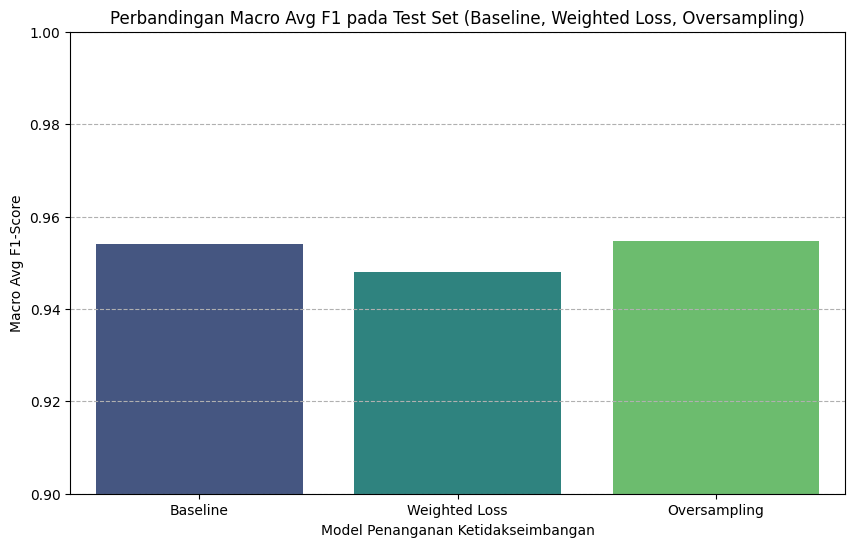

Visualisasi selesai.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pastikan df_results sudah ada dan berisi data perbandingan
if 'df_results' in locals() and not df_results.empty:

    print("\n--- Memvisualisasikan Perbandingan Macro Avg F1 (Baseline, Weighted Loss, Oversampling) ---")

    # Filter data untuk hanya menyertakan model yang diminta dan kolom 'Macro Avg F1'
    models_to_plot = ['Baseline', 'Weighted Loss', 'Oversampling']
    df_plot_macro_f1 = df_results.loc[models_to_plot, ['Macro Avg F1']].reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_plot_macro_f1, x='Model', y='Macro Avg F1', palette='viridis')
    plt.title('Perbandingan Macro Avg F1 pada Test Set (Baseline, Weighted Loss, Oversampling)')
    plt.xlabel('Model Penanganan Ketidakseimbangan')
    plt.ylabel('Macro Avg F1-Score')
    plt.ylim(0.9, 1.0) # Fokuskan plot pada rentang skor yang relevan
    plt.grid(axis='y', linestyle='--')
    plt.show()

    print("Visualisasi selesai.")

else:
    print("\nDataFrame df_results tidak ditemukan atau kosong. Jalankan kembali Blok 9 terlebih dahulu.")


--- Memvisualisasikan Perbandingan Minority Class F1 (Baseline, Weighted Loss, Oversampling) ---


/tmp/ipykernel_445/1293697880.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot_minority_f1, x='Model', y='Minority Class F1', palette='viridis')


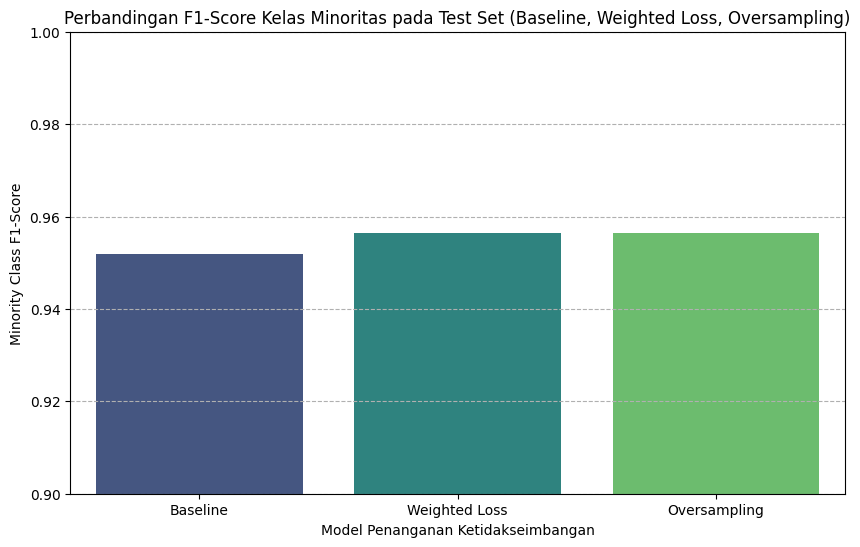

Visualisasi selesai.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pastikan df_results sudah ada dan berisi data perbandingan
if 'df_results' in locals() and not df_results.empty:

    print("\n--- Memvisualisasikan Perbandingan Minority Class F1 (Baseline, Weighted Loss, Oversampling) ---")

    # Filter data untuk hanya menyertakan model yang diminta dan kolom 'healthy_guava' (Minority Class F1)
    models_to_plot = ['Baseline', 'Weighted Loss', 'Oversampling']
    df_plot_minority_f1 = df_results.loc[models_to_plot, ['healthy_guava']].reset_index().rename(
        columns={'healthy_guava': 'Minority Class F1'}
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_plot_minority_f1, x='Model', y='Minority Class F1', palette='viridis')
    plt.title('Perbandingan F1-Score Kelas Minoritas pada Test Set (Baseline, Weighted Loss, Oversampling)')
    plt.xlabel('Model Penanganan Ketidakseimbangan')
    plt.ylabel('Minority Class F1-Score')
    plt.ylim(0.9, 1.0) # Fokuskan plot pada rentang skor yang relevan
    plt.grid(axis='y', linestyle='--')
    plt.show()

    print("Visualisasi selesai.")

else:
    print("\nDataFrame df_results tidak ditemukan atau kosong. Jalankan kembali Blok 9 terlebih dahulu.")

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan df_train_full dan df_test sudah ada
if 'df_train_full' in locals() and not df_train_full.empty and \
   'df_test' in locals() and not df_test.empty:

    print("\n--- Memvisualisasikan Perbandingan Distribusi Kelas (Train vs Test) ---")

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    sns.countplot(data=df_train_full, x='label', order=LABELS)
    plt.title('Distribusi Kelas Data Latih (Keseluruhan)')
    plt.xlabel('Kelas Penyakit')
    plt.ylabel('Jumlah Gambar')
    plt.xticks(rotation=45, ha='right')

    plt.subplot(1, 2, 2)
    sns.countplot(data=df_test, x='label', order=LABELS)
    plt.title('Distribusi Kelas Data Uji')
    plt.xlabel('Kelas Penyakit')
    plt.ylabel('Jumlah Gambar')
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

    print("Visualisasi selesai.")

else:
    print("\nDataFrame df_train_full atau df_test tidak ditemukan atau kosong. Jalankan kembali Blok 2 terlebih dahulu.")


DataFrame df_train_full atau df_test tidak ditemukan atau kosong. Jalankan kembali Blok 2 terlebih dahulu.



--- Memvisualisasikan Distribusi Kelas Data Latih Setelah Oversampling ---


/tmp/ipykernel_445/147323009.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train_balanced, x='label', order=LABELS, palette='viridis')


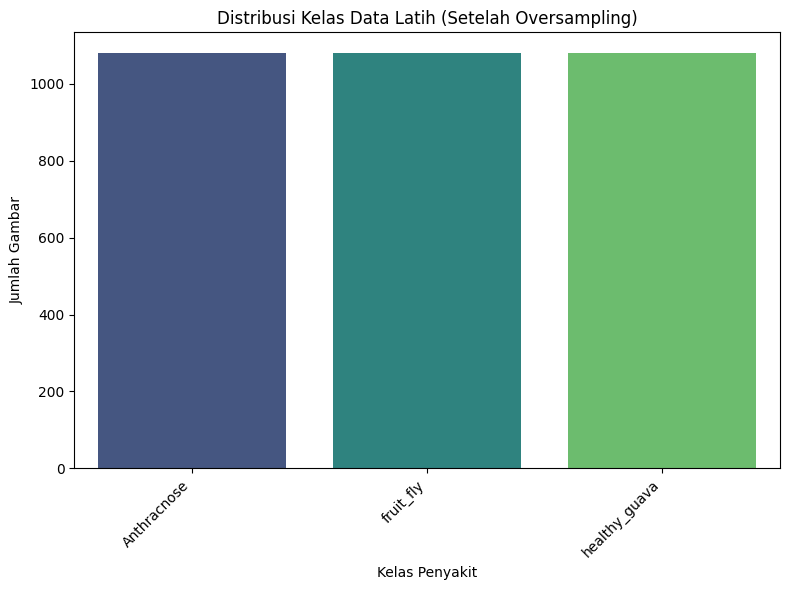

Visualisasi selesai.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan df_train_balanced sudah ada dan berisi data
if 'df_train_balanced' in locals() and not df_train_balanced.empty:

    print("\n--- Memvisualisasikan Distribusi Kelas Data Latih Setelah Oversampling ---")

    plt.figure(figsize=(8, 6))
    sns.countplot(data=df_train_balanced, x='label', order=LABELS, palette='viridis')
    plt.title('Distribusi Kelas Data Latih (Setelah Oversampling)')
    plt.xlabel('Kelas Penyakit')
    plt.ylabel('Jumlah Gambar')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print("Visualisasi selesai.")

else:
    print("\nDataFrame df_train_balanced tidak ditemukan atau kosong. Jalankan kembali Blok 7 terlebih dahulu.")


--- Memvisualisasikan Kurva Pelatihan Model Baseline ---


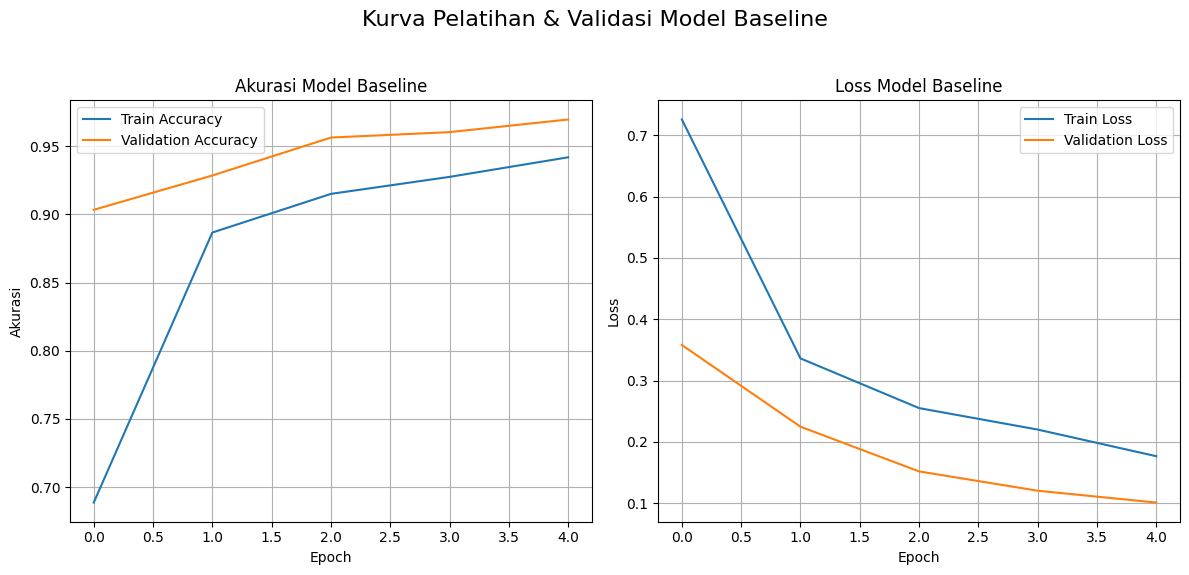

Visualisasi kurva model baseline selesai.


In [18]:
## Visualisasi Kurva Pelatihan Model Baseline

print("\n--- Memvisualisasikan Kurva Pelatihan Model Baseline ---")

# Pastikan history_baseline sudah ada
if 'history_baseline' in locals():
    history = history_baseline

    plt.figure(figsize=(12, 6))

    # Plot Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Akurasi Model Baseline')
    plt.xlabel('Epoch')
    plt.ylabel('Akurasi')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Model Baseline')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.suptitle('Kurva Pelatihan & Validasi Model Baseline', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("Visualisasi kurva model baseline selesai.")

else:
    print("\nVariabel 'history_baseline' tidak ditemukan. Pastikan Blok 5 (Eksperimen 1) sudah dijalankan.")

In [19]:
## Perbandingan Hasil 'Oversampling' vs 'Baseline'

print("\n--- Perbandingan Hasil Model 'Oversampling' vs 'Baseline' dari df_results ---")

# Pastikan df_results sudah ada dan berisi data
if 'df_results' in locals() and not df_results.empty:

    # Pilih baris untuk 'Baseline' dan 'Oversampling'
    comparison_models = ['Baseline', 'Oversampling']
    if all(model in df_results.index for model in comparison_models):
        df_comparison = df_results.loc[comparison_models]

        print("\nPerbandingan Hasil:")
        display(df_comparison)

        # Opsional: Tambahkan analisis singkat
        minority_class_name = label_counts_train.idxmin() # Asumsi label_counts_train masih ada
        print(f"\nAnalisis Singkat (Fokus pada kelas minoritas '{minority_class_name}'):")
        baseline_minority_f1 = df_comparison.loc['Baseline', minority_class_name]
        oversampling_minority_f1 = df_comparison.loc['Oversampling', minority_class_name]
        macro_avg_f1_baseline = df_comparison.loc['Baseline', 'Macro Avg F1']
        macro_avg_f1_oversampling = df_comparison.loc['Oversampling', 'Macro Avg F1']


        print(f"  F1-Score '{minority_class_name}':")
        print(f"    Baseline:     {baseline_minority_f1:.4f}")
        print(f"    Oversampling: {oversampling_minority_f1:.4f} (Perubahan: {oversampling_minority_f1 - baseline_minority_f1:+.4f})")

        print(f"  Macro Avg F1-Score:")
        print(f"    Baseline:     {macro_avg_f1_baseline:.4f}")
        print(f"    Oversampling: {macro_avg_f1_oversampling:.4f} (Perubahan: {macro_avg_f1_oversampling - macro_avg_f1_baseline:+.4f})")


    else:
        print("\nModel 'Baseline' atau 'Oversampling' tidak ditemukan dalam df_results.")


else:
    print("\nDataFrame df_results tidak ditemukan atau kosong. Jalankan kembali Blok 9 terlebih dahulu.")

print("\nPerbandingan selesai.")


--- Perbandingan Hasil Model 'Oversampling' vs 'Baseline' dari df_results ---

Perbandingan Hasil:


,Anthracnose,fruit_fly,healthy_guava,Macro Avg F1,Accuracy
Model,,,,,
Baseline,0.971609,0.938462,0.951872,0.953981,0.955497
Oversampling,0.965732,0.942085,0.956522,0.954780,0.955497



Analisis Singkat (Fokus pada kelas minoritas 'healthy_guava'):
  F1-Score 'healthy_guava':
    Baseline:     0.9519
    Oversampling: 0.9565 (Perubahan: +0.0047)
  Macro Avg F1-Score:
    Baseline:     0.9540
    Oversampling: 0.9548 (Perubahan: +0.0008)

Perbandingan selesai.



--- Memvisualisasikan Kurva Pelatihan Model Oversampling ---


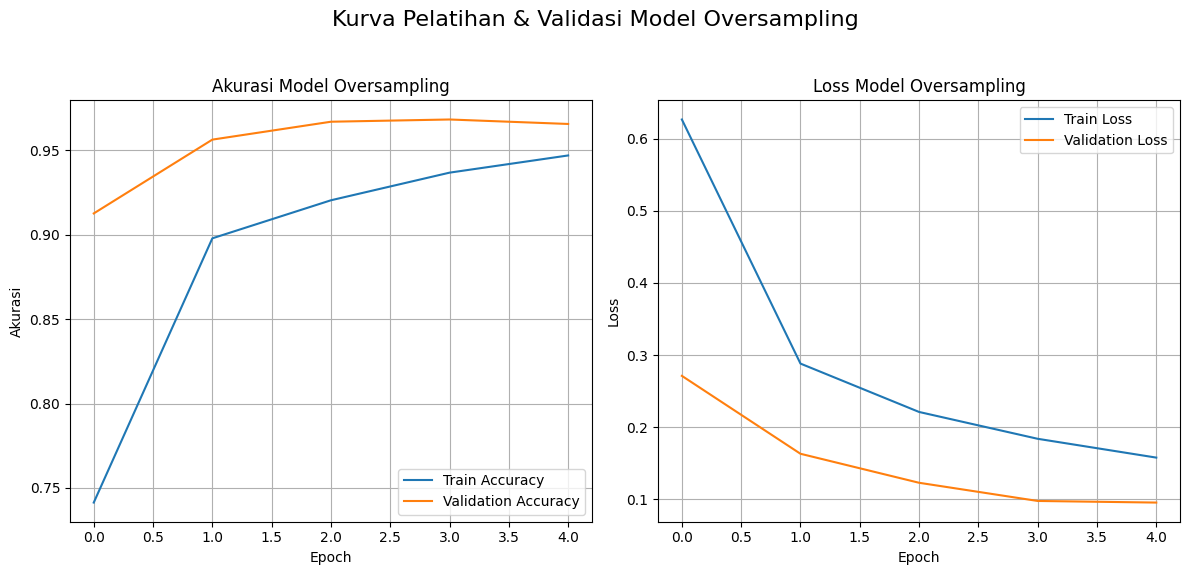

Visualisasi kurva model oversampling selesai.


In [20]:
## Visualisasi Kurva Pelatihan Model Oversampling

print("\n--- Memvisualisasikan Kurva Pelatihan Model Oversampling ---")

# Pastikan history_oversampled sudah ada
if 'history_oversampled' in locals():
    history = history_oversampled

    plt.figure(figsize=(12, 6))

    # Plot Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Akurasi Model Oversampling')
    plt.xlabel('Epoch')
    plt.ylabel('Akurasi')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Model Oversampling')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.suptitle('Kurva Pelatihan & Validasi Model Oversampling', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("Visualisasi kurva model oversampling selesai.")

else:
    print("\nVariabel 'history_oversampled' tidak ditemukan. Pastikan Blok 7 (Eksperimen 3) sudah dijalankan.")


--- Memvisualisasikan Kurva Pelatihan Model Weighted Loss ---


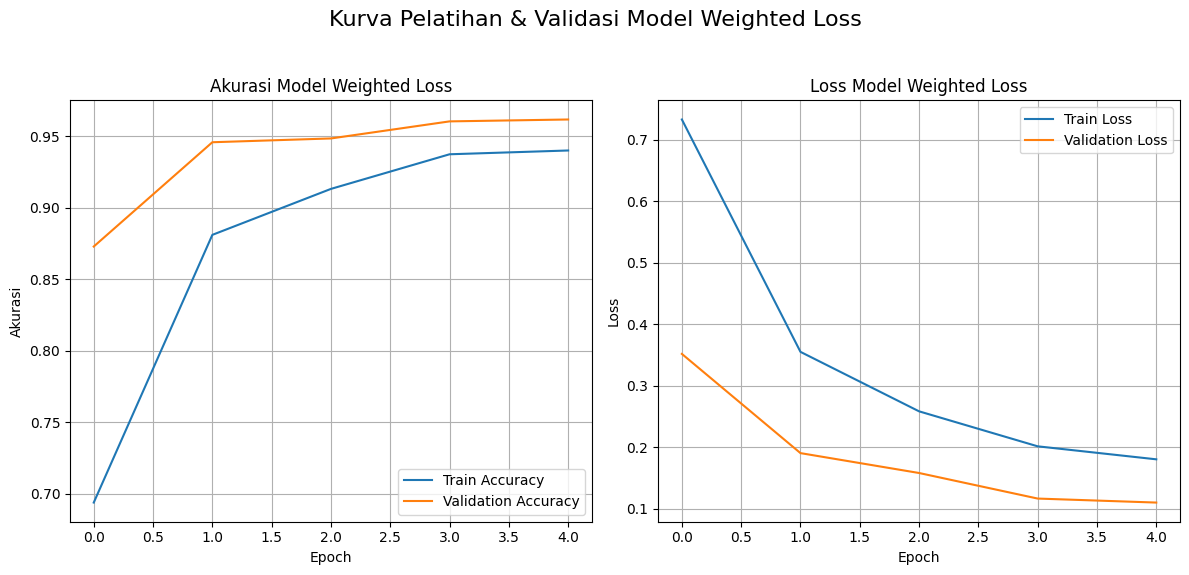

Visualisasi kurva model weighted loss selesai.


In [21]:
## Visualisasi Kurva Pelatihan Model Weighted Loss

print("\n--- Memvisualisasikan Kurva Pelatihan Model Weighted Loss ---")

# Pastikan history_weighted sudah ada
if 'history_weighted' in locals():
    history = history_weighted

    plt.figure(figsize=(12, 6))

    # Plot Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Akurasi Model Weighted Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Akurasi')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Model Weighted Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.suptitle('Kurva Pelatihan & Validasi Model Weighted Loss', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("Visualisasi kurva model weighted loss selesai.")

else:
    print("\nVariabel 'history_weighted' tidak ditemukan. Pastikan Blok 6 (Eksperimen 2) sudah dijalankan.")